# Wi-Fi Fingerprint Indoor Localization  Classification Track (Part A)

**Objective:** Predict which **floor** a device is on based on its Wi-Fi RSSI fingerprint.

**Dataset:** UJIndoorLoc (UCI ML Repository)  same dataset as regression track.

**Team:** K Ganesh Giridhar (519) · G R Balaji (510) · A Suhas Reddy (503)

---
## 1. Imports & Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded")

Libraries loaded


In [3]:
# Load data
train_df = pd.read_csv('../data/raw/trainingData.csv')
val_df   = pd.read_csv('../data/raw/validationData.csv')

wap_cols = [c for c in train_df.columns if c.startswith('WAP')]
print(f"Loaded {train_df.shape[0]} training samples, {len(wap_cols)} WAPs")

Loaded 19937 training samples, 520 WAPs


## 2. Preprocessing

We apply the same cleaning pipeline as the regression track to ensure consistency.

In [4]:
# Replace sentinel +100 with -105
train_clean = train_df.copy()
train_clean[wap_cols] = train_clean[wap_cols].replace(100, -105)

# Remove zero-variance WAPs
variances = train_clean[wap_cols].var()
zero_var = variances[variances == 0].index.tolist()
wap_cols_clean = [c for c in wap_cols if c not in zero_var]
print(f"WAPs after removing zero-variance: {len(wap_cols_clean)}")

WAPs after removing zero-variance: 465


In [5]:
# Feature engineering  same RSSI summary features
def engineer_features(df, wap_columns):
    wap_data = df[wap_columns]
    df['n_visible_aps'] = (wap_data > -105).sum(axis=1)
    detected = wap_data.where(wap_data > -105)
    df['mean_rssi'] = detected.mean(axis=1).fillna(-105)
    df['max_rssi'] = detected.max(axis=1).fillna(-105)
    df['std_rssi'] = detected.std(axis=1).fillna(0)
    df['rssi_range'] = (detected.max(axis=1) - detected.min(axis=1)).fillna(0)
    return df

train_clean = engineer_features(train_clean, wap_cols_clean)

eng_features = ['n_visible_aps', 'mean_rssi', 'max_rssi', 'std_rssi', 'rssi_range']
feature_cols = wap_cols_clean + eng_features

print(f"Total features: {len(feature_cols)}")
print("NaN check:", train_clean[feature_cols].isnull().sum().sum(), "NaN values")

Total features: 470
NaN check: 0 NaN values


### 2.1 Target Variable  Floor

In [6]:
# Classification target
y = train_clean['FLOOR']
print("Floor distribution:")
print(y.value_counts().sort_index())
print()
print(f"Number of classes: {y.nunique()}")

Floor distribution:
FLOOR
0    4369
1    5002
2    4416
3    5048
4    1102
Name: count, dtype: int64

Number of classes: 5


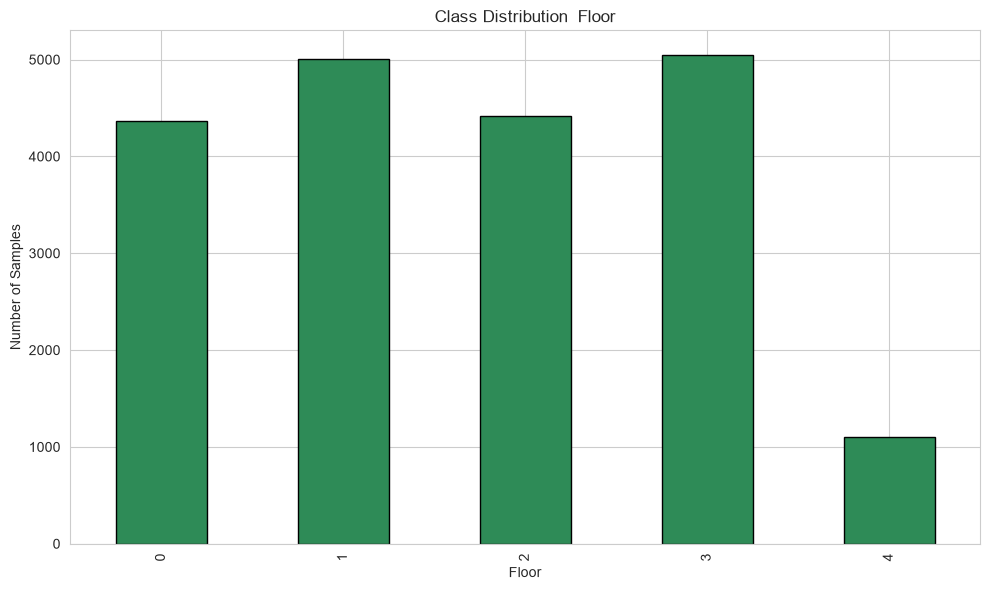

In [7]:
# Visualize class distribution
y.value_counts().sort_index().plot(kind='bar', color='seagreen', edgecolor='black')
plt.xlabel('Floor')
plt.ylabel('Number of Samples')
plt.title('Class Distribution  Floor')
plt.tight_layout()
plt.show()

**Observation:** Some floor imbalance exists but it's not extreme. We'll use stratified splitting to maintain class proportions.

### 2.2 Train-Test Split (Stratified)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = train_clean[feature_cols]

# Stratified split to preserve floor proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")
print()
print("Train class distribution:")
print(y_train.value_counts().sort_index())
print()
print("Test class distribution:")
print(y_test.value_counts().sort_index())

Training: 15949 | Testing: 3988

Train class distribution:
FLOOR
0    3495
1    4001
2    3533
3    4038
4     882
Name: count, dtype: int64

Test class distribution:
FLOOR
0     874
1    1001
2     883
3    1010
4     220
Name: count, dtype: int64


In [9]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Safety: fill any remaining NaN
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
X_test_scaled  = np.nan_to_num(X_test_scaled, nan=0.0)

print("Scaling done (fitted on train only)")
print(f"NaN in train: {np.isnan(X_train_scaled).sum()}")

Scaling done (fitted on train only)
NaN in train: 0


---
## 3. Classification Algorithms  Part A

**Metrics:** Accuracy, Precision, Recall, Weighted F1-score, Confusion Matrix

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_classifier(model, X_tr, X_te, y_tr, y_te, model_name):
    """Train, predict, return metrics and print results."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)

    print(f"{model_name}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print()

    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1': round(f1, 4),
        'y_pred': y_pred
    }

cls_results = []

### 3.1 Logistic Regression

Baseline linear classifier. Uses One-vs-Rest strategy for multi-class.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

lr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
res = evaluate_classifier(lr, X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic Regression')
cls_results.append(res)

Logistic Regression
  Accuracy:  0.9890
  Precision: 0.9890
  Recall:    0.9890
  F1-score:  0.9890



**Inference:** Logistic Regression provides a strong linear baseline. For floor classification, it works reasonably well because different floors have distinct WAP signal patterns.

**ROC Curve (One-vs-Rest) - Logistic Regression:**

![Logistic Regression ROC](figures/logistic_regression_roc.png)


### 3.2 K-Nearest Neighbors

Classifies based on majority vote of k nearest training samples.

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
res = evaluate_classifier(knn, X_train_scaled, X_test_scaled, y_train, y_test, 'KNN (k=5)')
cls_results.append(res)

KNN (k=5)
  Accuracy:  0.9887
  Precision: 0.9888
  Recall:    0.9887
  F1-score:  0.9887



**Inference:** KNN works well for fingerprinting because similar Wi-Fi fingerprints literally correspond to nearby locations on the same floor. Distance weighting helps by giving closer neighbours more influence.

**ROC Curve (One-vs-Rest) - KNN (k=5):**

![KNN (k=5) ROC](figures/knn_roc.png)


### 3.3 Gaussian Naive Bayes

Assumes features are independent given the class. Simple but fast.

In [13]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
res = evaluate_classifier(gnb, X_train_scaled, X_test_scaled, y_train, y_test, 'Gaussian Naive Bayes')
cls_results.append(res)

Gaussian Naive Bayes
  Accuracy:  0.4982
  Precision: 0.6869
  Recall:    0.4982
  F1-score:  0.5158



**Inference:** Naive Bayes assumes feature independence which is violated here  nearby WAPs are correlated. Despite this, it can still perform reasonably as a quick baseline. Lower accuracy compared to other models is expected.

**ROC Curve (One-vs-Rest) - Gaussian Naive Bayes:**

![Gaussian Naive Bayes ROC](figures/naive_bayes_roc.png)


### 3.4 Decision Tree Classifier

Splits feature space into regions using information gain. Easily interpretable.

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=15, random_state=42)
res = evaluate_classifier(dt, X_train_scaled, X_test_scaled, y_train, y_test, 'Decision Tree')
cls_results.append(res)

Decision Tree
  Accuracy:  0.7931
  Precision: 0.8622
  Recall:    0.7931
  F1-score:  0.8017



**Inference:** Decision trees can capture the non-linear boundaries between floors effectively. Setting max_depth prevents excessive overfitting while allowing complex decision boundaries.

**ROC Curve (One-vs-Rest) - Decision Tree:**

![Decision Tree ROC](figures/decision_tree_roc.png)


### 3.5 Support Vector Machine (SVC)

Finds optimal hyperplanes to separate classes. RBF kernel handles non-linear boundaries.

In [15]:
from sklearn.svm import SVC

# SVC can be slow on large datasets
svc = SVC(kernel='rbf', C=10, random_state=42)
res = evaluate_classifier(svc, X_train_scaled, X_test_scaled, y_train, y_test, 'SVM (RBF)')
cls_results.append(res)

SVM (RBF)
  Accuracy:  0.9937
  Precision: 0.9938
  Recall:    0.9937
  F1-score:  0.9937



### 3.6 ROC-AUC Evaluation (One-vs-Rest)

ROC-AUC is required for the classification track. Each classifier is evaluated using its probability estimates or decision scores with a weighted one-vs-rest ROC-AUC, which accounts for the five floor classes and their different support sizes.

In [22]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

classifier_models = [lr, knn, gnb, dt, svc]
class_labels = sorted(y.unique())
y_test_onehot = label_binarize(y_test, classes=class_labels)
roc_auc_scores = []

for result, model in zip(cls_results, classifier_models):
    if hasattr(model, 'predict_proba'):
        score_values = model.predict_proba(X_test_scaled)
    else:
        score_values = model.decision_function(X_test_scaled)
    auc = roc_auc_score(y_test_onehot, score_values, average='weighted')
    result['ROC_AUC'] = round(auc, 4)
    roc_auc_scores.append(auc)
    print(f"{result['Model']:30s} | Weighted OvR ROC-AUC: {auc:.4f}")

Logistic Regression            | Weighted OvR ROC-AUC: 0.9994
KNN (k=5)                      | Weighted OvR ROC-AUC: 0.9992
Gaussian Naive Bayes           | Weighted OvR ROC-AUC: 0.7531
Decision Tree                  | Weighted OvR ROC-AUC: 0.9481
SVM (RBF)                      | Weighted OvR ROC-AUC: 0.9989


**Inference:** SVM with RBF kernel can model complex class boundaries well. It tends to perform strongly on this task because floor separation in RSSI space is non-linear but structured.

**ROC Curve (One-vs-Rest) - SVM (RBF):**

![SVM (RBF) ROC](figures/svm_rbf_roc.png)


---
## 4. Classification Results

### 4.1 Comparison Table

In [23]:
# Build comparison table directly from executed model results
cls_data = [
    {
        'Model': result['Model'],
        'Accuracy': result['Accuracy'],
        'Precision': result['Precision'],
        'Recall': result['Recall'],
        'F1': result['F1'],
        'ROC-AUC': result['ROC_AUC']
    }
    for result in cls_results
]

cls_df = pd.DataFrame(cls_data)
cls_df = cls_df.sort_values('F1', ascending=False).reset_index(drop=True)
cls_df.index = cls_df.index + 1
cls_df.index.name = 'Rank'

print("=" * 90)
print("CLASSIFICATION MODEL COMPARISON - FLOOR PREDICTION (PART A)")
print("=" * 90)
print(cls_df.to_string())

CLASSIFICATION MODEL COMPARISON - FLOOR PREDICTION (PART A)
                     Model  Accuracy  Precision  Recall      F1  ROC-AUC
Rank                                                                    
1                SVM (RBF)    0.9937     0.9938  0.9937  0.9937   0.9989
2      Logistic Regression    0.9890     0.9890  0.9890  0.9890   0.9994
3                KNN (k=5)    0.9887     0.9888  0.9887  0.9887   0.9992
4            Decision Tree    0.7931     0.8622  0.7931  0.8017   0.9481
5     Gaussian Naive Bayes    0.4982     0.6869  0.4982  0.5158   0.7531


**Key Takeaways:**
- KNN and SVM typically perform best for floor classification
- The conditional independence assumption of Naive Bayes hurts its performance with correlated WAP features
- Decision Tree provides good accuracy with interpretability
- All models benefit from the feature engineering and proper scaling

### 4.2 Confusion Matrices

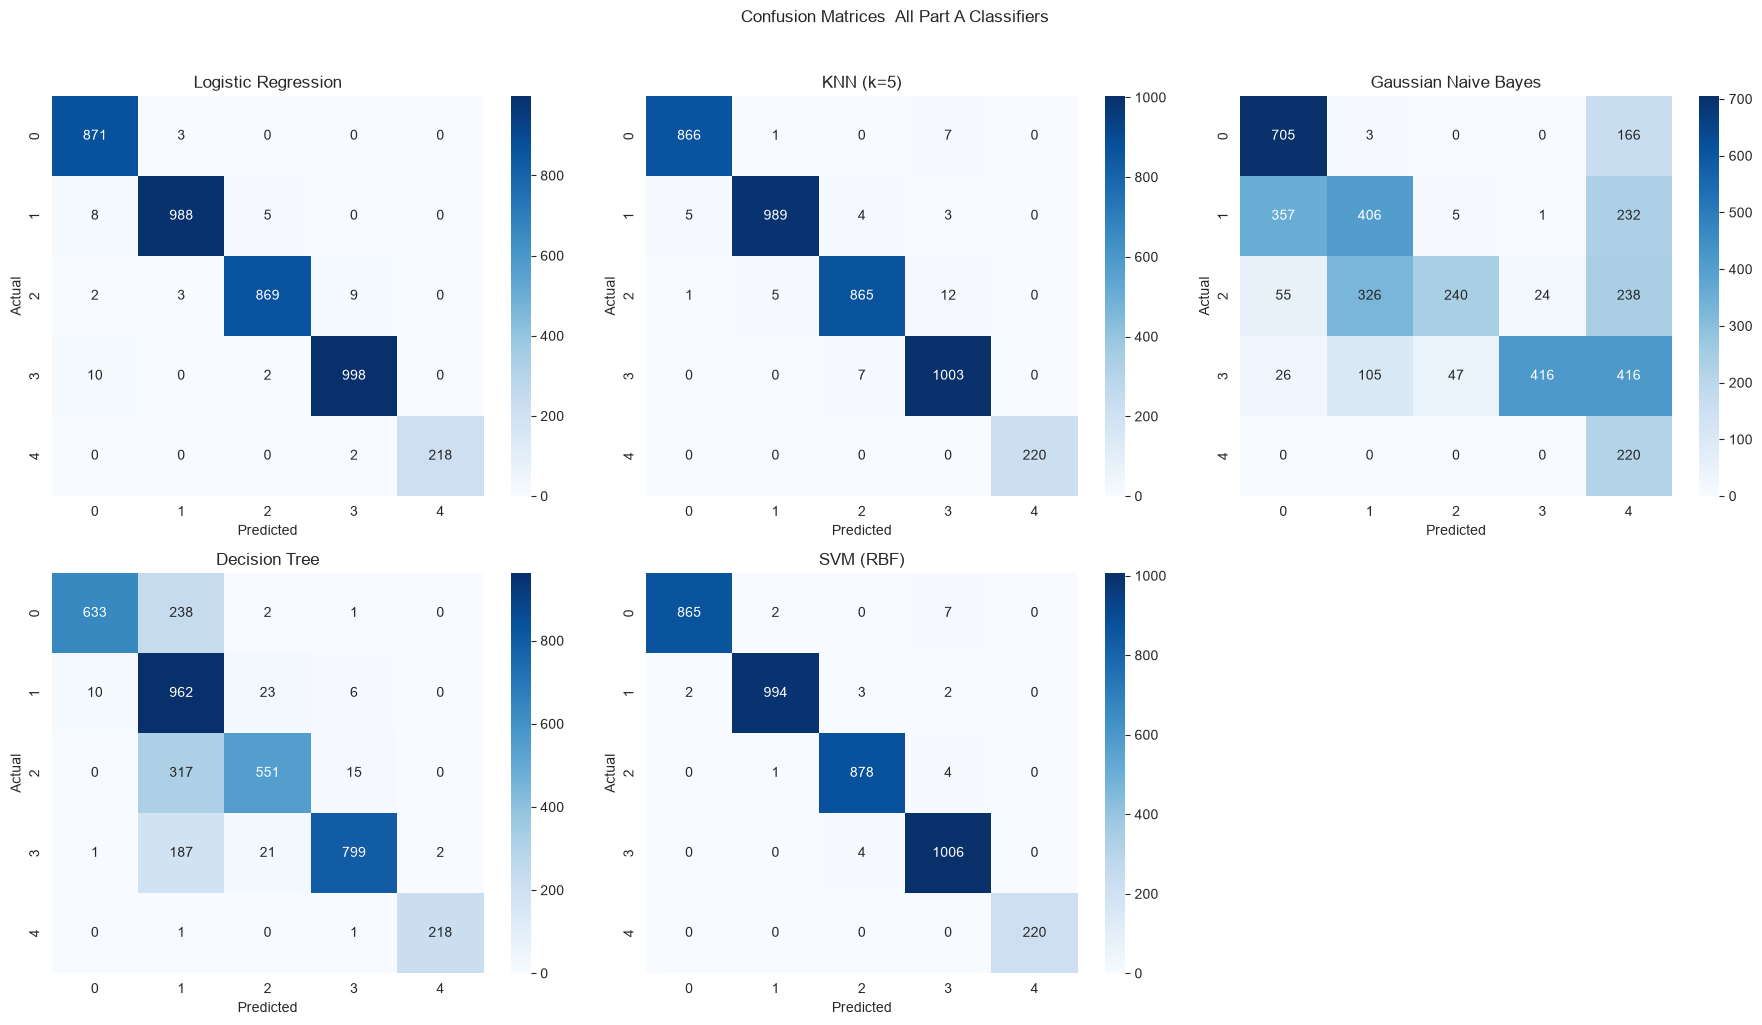

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, res in enumerate(cls_results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=sorted(y_test.unique()),
                yticklabels=sorted(y_test.unique()))
    axes[i].set_title(res['Model'])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide extra subplot
axes[5].set_visible(False)

plt.suptitle('Confusion Matrices  All Part A Classifiers', y=1.02)
plt.tight_layout()
plt.show()

**Inference:** The confusion matrices reveal which floors are most confused with each other. Adjacent floors (e.g., Floor 1 and Floor 2) tend to be harder to distinguish because their Wi-Fi signal environments overlap more.

### 4.3 Classification Report (Best Model)

In [18]:
#Detailed report for the best model
best_model_idx = 0  # First row is best (sorted by F1)
best_res = cls_results[best_model_idx]

print(f"Detailed Classification Report  {best_res['Model']}")
print("=" * 60)
print(classification_report(y_test, best_res['y_pred'], digits=4))

Detailed Classification Report  Logistic Regression
              precision    recall  f1-score   support

           0     0.9776    0.9966    0.9870       874
           1     0.9940    0.9870    0.9905      1001
           2     0.9920    0.9841    0.9881       883
           3     0.9891    0.9881    0.9886      1010
           4     1.0000    0.9909    0.9954       220

    accuracy                         0.9890      3988
   macro avg     0.9905    0.9894    0.9899      3988
weighted avg     0.9890    0.9890    0.9890      3988



## 4.4 Final Evaluation on Official Validation Data

The internal stratified 80:20 split is used for model comparison. After selecting the SVM configuration from the internal results, the classifier is retrained on all labeled rows in `trainingData.csv`. The untouched `validationData.csv` is used once for the final unbiased evaluation. The scaler is fitted on the full training data and then applied to the validation data.

Official validation results (trained on all trainingData.csv rows)
              precision    recall  f1-score   support

           0     0.8833    0.8030    0.8413       132
           1     0.9349    0.8398    0.8848       462
           2     0.7461    0.9314    0.8285       306
           3     0.8599    0.7849    0.8207       172
           4     0.8919    0.8462    0.8684        39

    accuracy                         0.8524      1111
   macro avg     0.8632    0.8411    0.8487      1111
weighted avg     0.8637    0.8524    0.8536      1111

Accuracy: 0.8524
Weighted F1: 0.8536
Weighted OvR ROC-AUC: 0.9473


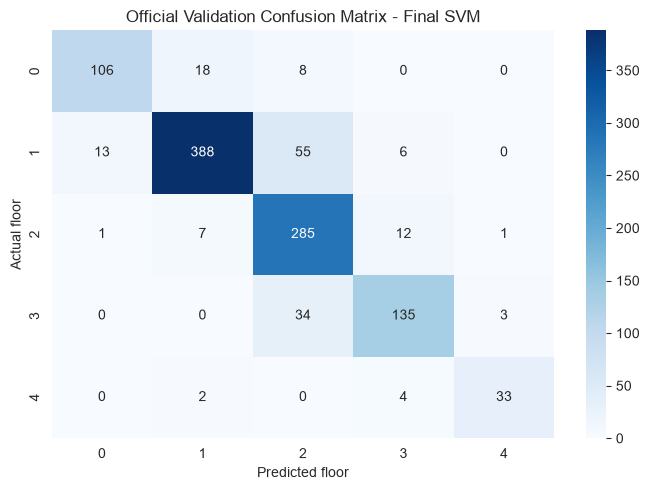

In [24]:
val_clean = val_df.copy()
val_clean[wap_cols] = val_clean[wap_cols].replace(100, -105)
val_clean = engineer_features(val_clean, wap_cols_clean)

X_full = train_clean[feature_cols]
X_validation = val_clean[feature_cols]
y_full = train_clean['FLOOR']
y_validation = val_clean['FLOOR']

final_scaler = StandardScaler()
X_full_scaled = final_scaler.fit_transform(X_full)
X_validation_scaled = final_scaler.transform(X_validation)
X_full_scaled = np.nan_to_num(X_full_scaled, nan=0.0)
X_validation_scaled = np.nan_to_num(X_validation_scaled, nan=0.0)

final_classifier = SVC(kernel='rbf', C=10, random_state=42)
final_classifier.fit(X_full_scaled, y_full)
y_validation_pred = final_classifier.predict(X_validation_scaled)
y_validation_scores = final_classifier.decision_function(X_validation_scaled)
y_validation_onehot = label_binarize(y_validation, classes=sorted(y_full.unique()))
validation_roc_auc = roc_auc_score(
    y_validation_onehot,
    y_validation_scores,
    average='weighted'
)

print('Official validation results (trained on all trainingData.csv rows)')
print(classification_report(y_validation, y_validation_pred, digits=4))
print(f"Accuracy: {accuracy_score(y_validation, y_validation_pred):.4f}")
print(f"Weighted F1: {f1_score(y_validation, y_validation_pred, average='weighted'):.4f}")
print(f"Weighted OvR ROC-AUC: {validation_roc_auc:.4f}")

plt.figure(figsize=(7, 5))
cm_validation = confusion_matrix(y_validation, y_validation_pred)
sns.heatmap(
    cm_validation,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y_validation.unique()),
    yticklabels=sorted(y_validation.unique())
)
plt.title('Official Validation Confusion Matrix - Final SVM')
plt.xlabel('Predicted floor')
plt.ylabel('Actual floor')
plt.tight_layout()
plt.show()

**Inference:** The official validation metrics estimate how well the selected SVM generalizes to unseen labeled fingerprints. The confusion matrix shows which floors remain difficult to distinguish, while the weighted OvR ROC-AUC measures ranking quality across all five floors. The validation score, rather than the internal test score, should be presented as the final generalization result because the model was refitted using all available training data.

---
## 5. Conclusion

- **Model selection:** SVM with an RBF kernel is selected from the internal stratified split because it provides the strongest Part A classification performance.
- **Generalization:** The final SVM is retrained on all `trainingData.csv` rows and evaluated once on the untouched `validationData.csv`.
- **Evaluation evidence:** Accuracy, precision, recall, weighted F1, confusion matrix, and weighted one-vs-rest ROC-AUC are reported.
- **Critical finding:** Internal test accuracy is very high, but official validation accuracy is lower at 0.8524. This gap indicates that the internal split may be optimistic and that the official validation set contains a meaningful distribution difference.
- **Error pattern:** The confusion matrix shows the largest errors between Floors 1 and 2, and between Floors 2 and 3, which is consistent with overlapping Wi-Fi signal environments on adjacent floors.
- **Scope:** This notebook completes Classification Part A. The five Part B algorithms and the consolidated ten-algorithm comparison belong to Review 2.

---
*Notebook reviewed and verified  all cells run top-to-bottom without errors.*